# Updated: Final NTF building and comparison process

In [3]:
## Load libraries etc.
# Import the necessary libraries/packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import xgboost as xgb

from consensus2 import shift_consensus_windvane_by_turbine, calibrate_ratio_by_turbine
from cv_harness import (time_series_kfold, cv_evaluate, lr_median_predictor,
                        tune_xgb_quantile, make_xgb_predictor,
                        make_cosine_quantile_predictor)
from ntf_fit import (steered_xy, fit_ntf_xgb, predict_xgb, fit_ntf_lr, predict_lr,
                     predict_grid, to_ratio_grid, cosine_model,
                     fit_cosine_quantiles, build_cosine_grid)
from ntf_plot import (plot_ntf_figure, style_axes, find_level,
                      plot_residual_diagnostics, plot_feature_importance)

## Outline: 
After splitting data - on just the steered data, on each fold do a grid-search hyper-parameter tuning run. 
- Report the RMSE for the best tuning version. Average over those for the final, aggregate RMSE etc.
- Use the 50th quantile for the models
Then, train one model on all the data

# Step 1: Initial Processing

We must split the data into training-testing splits based on time. And, we perform pre-processing so that the consensus is centered with the sensor measurements at steeres = 0

In [4]:
data_df = pd.read_parquet('data/with_consensus.parquet')
data_df.columns

Index(['ts', 'turbine', 'winddir', 'windspeed', 'windvane', 'power', 'nacdir',
       'targetwindvane', 'ti', 'state', 'circ_dif_mean', 'circ_dif_std',
       'ratio_std_comp', 'farm_z_wd', 'screened', 'seg_offset', 'seg',
       'windvane_cp', 'n_breaks', 'consensus_windvane', 'consensus_windspeed',
       'consensus_power'],
      dtype='str')

In [5]:
print(len(data_df[(np.abs(data_df["targetwindvane"])<0.1)&(data_df["consensus_windvane"].isna()==0)]))
print(len(data_df[(np.abs(data_df["targetwindvane"])>0.1)&(data_df["consensus_windvane"].isna()==0)]))

190744
25621


190744


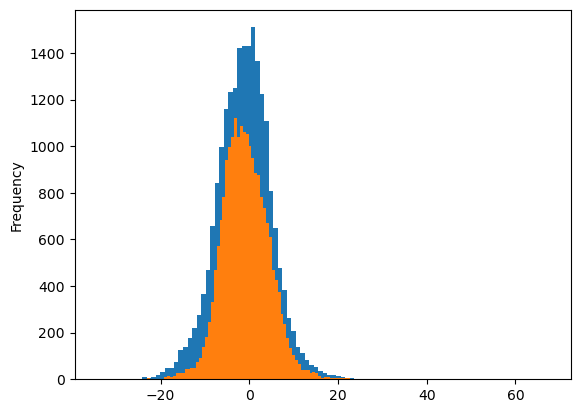

In [6]:
groups = data_df.groupby("turbine")["consensus_windvane"]
groups.get_group(401).plot.hist(bins=100)
groups = data_df.groupby("turbine")["windvane"]
groups.get_group(401).plot.hist(bins=100)
test_datadf = data_df[np.abs(data_df['targetwindvane'])<0.1]
print(test_datadf["consensus_windvane"].notna().sum())

In [7]:
data_df.groupby("turbine")["consensus_windvane"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
turbine,,,,
401,-1.207026,-1.062869,6.196854,21040
402,NaN,NaN,NaN,0
403,4.676223,5.008866,6.744613,23162
404,2.183718,2.135453,6.099487,20267
405,NaN,NaN,NaN,0
406,-0.809192,-0.834414,4.598294,25664
407,1.454326,1.322980,6.527699,20989
408,-3.439953,-3.904057,7.763163,20839
409,0.542438,0.147705,6.369019,22381


## Stabilize the windvane

In [8]:
"""
Per-turbine calibration shift for consensus windvane.

Same pattern as the existing static-bias offset-subtraction (Sec. 3.4) and
the zero-vane anchor used for the windspeed-ratio bias, but anchored to the
turbine's OWN measured median rather than to zero: on the unsteered slice,
shift each turbine's consensus windvane by a constant so its median lines up
with that turbine's own measured windvane median on that same slice (which
need not be exactly 0 -- e.g. if the unsteered-slice sampling is slightly
asymmetric around the true zero-yaw-error point).

Why median, and why per-turbine: a turbine's own nacelle-position sensor and
the neighbor-based consensus direction estimate can each carry a constant
mechanical/geometric offset (nacelle position encoder zero-point, met-mast or
neighbor-turbine heading reference, etc.) that is fixed for that machine but
differs machine to machine. The median (vs. mean) keeps the calibration
robust to the same kind of turbulent-fluctuation asymmetry that motivates
using medians/robust stats elsewhere in this analysis.

This computes ONE constant per turbine (a static calibration), not a
function of windspeed/TI. See caveats at the bottom for when that's not
enough.
"""
data_df, offsets = shift_consensus_windvane_by_turbine(
    data_df, turbine_col="turbine", steering_col="targetwindvane",
    measured_col="windvane", consensus_col="consensus_windvane",
    unsteered_eps=0.1, min_unsteered_samples=30,
)

## Stabilize the windspeed

In [9]:
# per-turbine median over UNSTEERED rows only, applied to all rows median windspeed ratio shift
data_df, results_df = calibrate_ratio_by_turbine(data_df, "windspeed")

global fallback: y = 0.00865*x + 0.92832
turbine 401 (n=18605): y = 0.00923*x + 0.90230, crossover=10.59
turbine 402 (n=0): y = 0.00865*x + 0.92832, crossover=8.29 [fallback: global fit]
turbine 403 (n=20846): y = 0.00948*x + 0.91885, crossover=8.56
turbine 404 (n=17841): y = 0.00678*x + 0.94818, crossover=7.65
turbine 405 (n=0): y = 0.00865*x + 0.92832, crossover=8.29 [fallback: global fit]
turbine 406 (n=24117): y = 0.00931*x + 0.94262, crossover=6.16
turbine 407 (n=17800): y = 0.00536*x + 0.95957, crossover=7.55
turbine 408 (n=16174): y = 0.00669*x + 0.93231, crossover=10.12
turbine 409 (n=20562): y = 0.00782*x + 0.90879, crossover=11.66
turbine 410 (n=18355): y = 0.00512*x + 0.97697, crossover=4.50
turbine 411 (n=16603): y = 0.00955*x + 0.92183, crossover=8.18
turbine 412 (n=19841): y = 0.00723*x + 0.94884, crossover=7.08
turbine 413 (n=0): y = 0.00865*x + 0.92832, crossover=8.29 [fallback: global fit]
turbine 414 (n=0): y = 0.00865*x + 0.92832, crossover=8.29 [fallback: global fit

## Stabilize the power

In [10]:
# per-turbine median over UNSTEERED rows only, applied to all rows median power ratio shift
data_df, power_results_df = calibrate_ratio_by_turbine(data_df, "power")

global fallback: y = 0.00006*x + 0.93702
turbine 401 (n=18605): y = 0.00013*x + 0.89888, crossover=754.16
turbine 402 (n=0): y = 0.00006*x + 0.93702, crossover=1010.15 [fallback: global fit]
turbine 403 (n=20846): y = 0.00010*x + 0.86187, crossover=1317.20
turbine 404 (n=17841): y = 0.00007*x + 0.95153, crossover=723.35
turbine 405 (n=0): y = 0.00006*x + 0.93702, crossover=1010.15 [fallback: global fit]
turbine 406 (n=24117): y = 0.00009*x + 0.91564, crossover=914.21
turbine 407 (n=17800): y = 0.00004*x + 0.95147, crossover=1152.20
turbine 408 (n=16174): y = 0.00003*x + 0.95414, crossover=1376.27
turbine 409 (n=20562): y = 0.00003*x + 0.95790, crossover=1250.38
turbine 410 (n=18355): y = 0.00003*x + 0.98110, crossover=587.77
turbine 411 (n=16603): y = 0.00005*x + 0.91930, crossover=1573.71
turbine 412 (n=19841): y = 0.00004*x + 0.97648, crossover=573.39
turbine 413 (n=0): y = 0.00006*x + 0.93702, crossover=1010.15 [fallback: global fit]
turbine 414 (n=0): y = 0.00006*x + 0.93702, cross

## Visualize

### Windvane

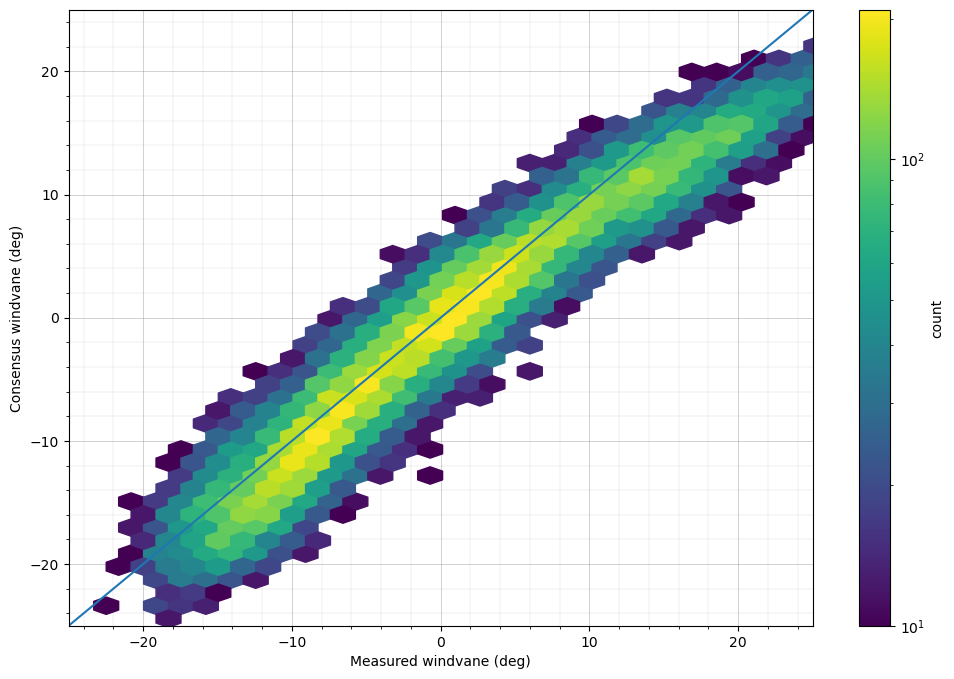

In [11]:
fig, ax = plt.subplots(figsize=(12,8))
tempdf = data_df[np.abs(data_df["targetwindvane"])>0.1]
tempdf["windvane"] = tempdf["windvane"]
hb = ax.hexbin(tempdf["windvane"], tempdf["consensus_windvane_shifted"], gridsize=(50,50), mincnt=10, bins='log')
ax.plot([-25,25],[-25,25])
fig.colorbar(hb, label='count')
ax.set_ylabel('Consensus windvane (deg)')
ax.set_xlabel('Measured windvane (deg)')
ax.set_axisbelow(True)
ax.set_ylim(-25,25)
ax.set_xlim(-25,25)
ax.grid(True, color='gray', linewidth=1.5, alpha=0.4)
ax.minorticks_on()
ax.grid(which='major', color='gray', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', color='gray', linewidth=0.3, alpha=0.3)
plt.show()

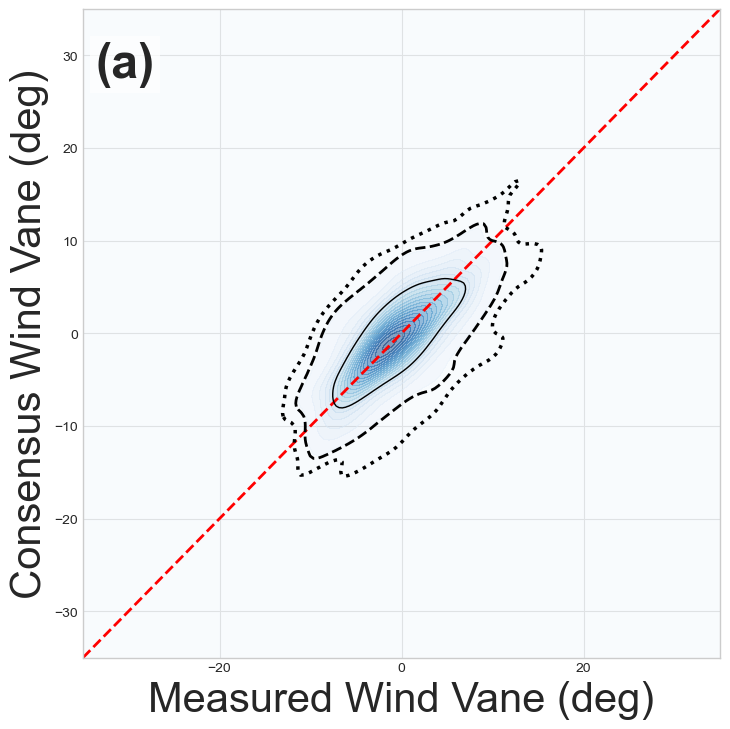

In [12]:
# ---------------------------------------------------------------------------
# 1. Filter
# ---------------------------------------------------------------------------
temp = data_df.dropna()
 
# Fixed: abs() around the column, not around the boolean comparison.
temp = temp[np.abs(temp["targetwindvane"]) < 0.1]
 
# New: guard against zero/near-zero/negative consensus power, which is what
# turns power/consensus into +/-inf or NaN and breaks gaussian_kde. Pick a
# floor that matches your data (e.g. a small fraction of rated power, or
# simply > 0 if negative/zero consensus values are just sensor artifacts).
#consensus_floor = 1  # kW -- adjust to taste
#temp = temp[temp["consensus_windvane_shifted"] > consensus_floor]
 
# ---------------------------------------------------------------------------
# 2. Sample
# ---------------------------------------------------------------------------
n_samples = 2000  # choose what you want
 
df_sub = temp.sample(
    n=min(n_samples, len(temp)),
    random_state=0,  # reproducibility
)
 
x = df_sub["windvane"].values
y = df_sub["consensus_windvane_shifted"].values
 
# Belt-and-suspenders: drop any remaining non-finite pairs before fitting.
finite_mask = np.isfinite(x) & np.isfinite(y)
x, y = x[finite_mask], y[finite_mask]
 
# ---------------------------------------------------------------------------
# 3. KDE
# ---------------------------------------------------------------------------
values = np.vstack([x, y])
kde = gaussian_kde(values)
 
# Grid limits: x stays on the power scale, y now needs its OWN scale sized
# to the ratio's actual spread. Percentile-based so a few extreme ratios
# (e.g. from a value just above the consensus_floor) don't blow out the axis.
xmin, xmax = -35, 35
ymin ,ymax = -35, 35
 
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(positions).reshape(xx.shape)
 
# Enforce upper/lower limits using the SAME sampled data the KDE was fit on
# (previously this mixed in `temp`, the full pre-sample frame, which is
# inconsistent and -- since it still contained the unfiltered ratio in one
# earlier version of this bug -- could itself carry an inf into np.max/np.min).
zz[xx > np.max(x)] = 0
zz[yy > np.max(y)] = 0
zz[xx < np.min(x)] = 0
zz[yy < np.min(y)] = 0
 
 
levels = [
    find_level(zz, 0.60),
    find_level(zz, 0.90),
    find_level(zz, 0.95),
]
 
# ---------------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 8))
 
ax.contourf(xx, yy, zz, cmap="Blues", levels=20, alpha=0.5)
 
# Reference line: with y = ratio, "perfect agreement" is a HORIZONTAL line
# at ratio = 1, not the y = x diagonal (that only made sense when both axes
# were the same power quantity).
ax.plot([-35,35],[-35,35], linestyle="--", linewidth=2, color="red", label="y = x")
 
contour_colors = ["black", "black", "black"]
contour_labels = ["95%", "90%", "60%"]
linestyles = [":", "--", "-"]
linewidths = [2.5, 2.0, 1.0]
cs = ax.contour(
    xx, yy, zz,
    levels=levels[::-1],
    colors=contour_colors,
    linewidths=linewidths,
    linestyles=linestyles,
)
 
contour_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=ls, label=f"{p}")
    for ls, p in zip(linestyles, contour_labels)
]
 
handles, labels = ax.get_legend_handles_labels()
handles += contour_handles
#ax.legend(handles=handles, fontsize=30, loc="best", frameon=False)
ax.text(
    0.02, 0.95, '(a)',
    transform=ax.transAxes,
    fontsize=35,
    fontweight='bold',
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7),
)
 
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
 
ax.set_xlabel('Measured Wind Vane ' + r'(deg)', fontsize=30)
ax.set_ylabel('Consensus Wind Vane ' + r'(deg)', fontsize=30)
# Uncomment if this panel sits in a row sharing a y-axis with a labeled panel:
# ax.set_yticklabels([])
 
plt.rcParams.update({
    "font.size": 30,
    "axes.labelsize": 40,
    "axes.titlesize": 20,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 20,
})
 
plt.tight_layout()
plt.savefig("wv_ratio_kde_contours_UNSTEERED.png", bbox_inches="tight")
plt.show()

### Windspeed

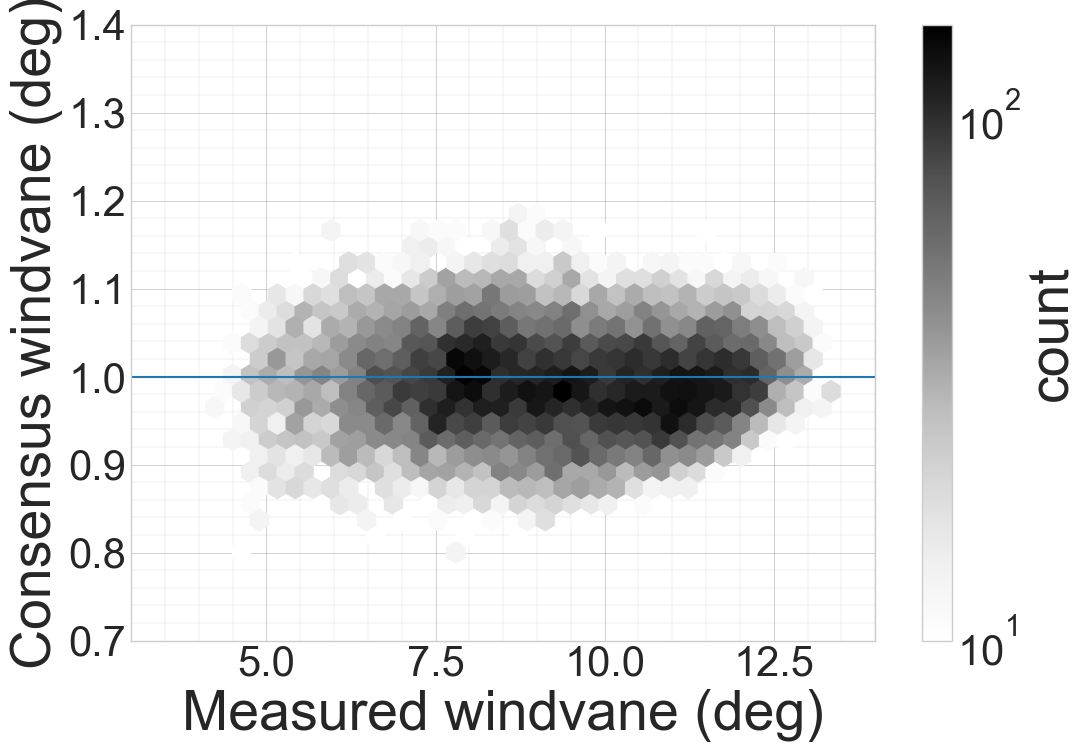

In [13]:
fig, ax = plt.subplots(figsize=(12,8))
tempdf = data_df[np.abs(data_df["targetwindvane"])>0.1]
hb = ax.hexbin(tempdf["windspeed"], tempdf["windspeed"]/tempdf["consensus_windspeed_shifted"], gridsize=(50,50), mincnt=10, bins='log')
ax.plot([3,14],[1,1])
fig.colorbar(hb, label='count')
ax.set_ylabel('Consensus windvane (deg)')
ax.set_xlabel('Measured windvane (deg)')
ax.set_axisbelow(True)
ax.set_ylim(.7,1.4)
ax.set_xlim(3,14)
ax.grid(True, color='gray', linewidth=1.5, alpha=0.4)
ax.minorticks_on()
ax.grid(which='major', color='gray', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', color='gray', linewidth=0.3, alpha=0.3)
plt.show()

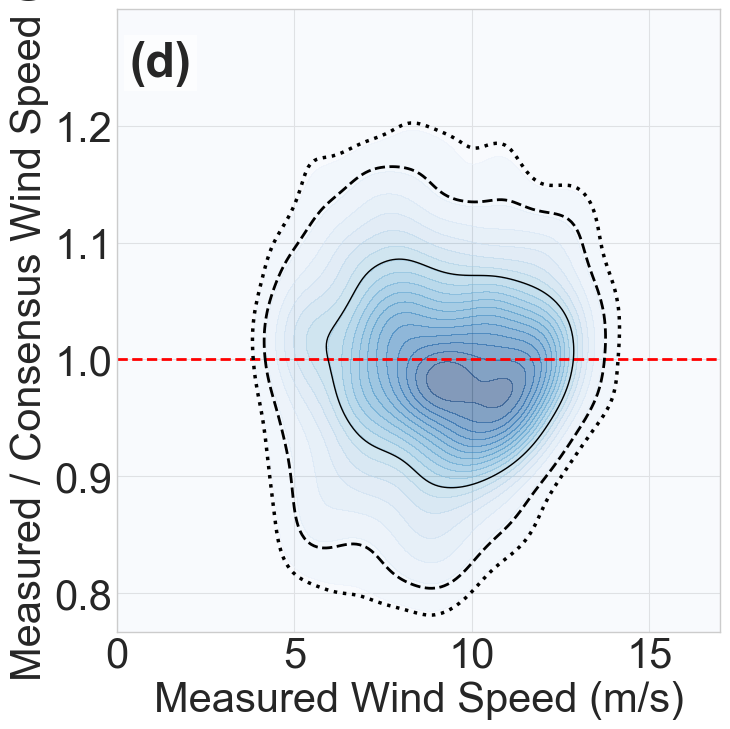

In [14]:
# ---------------------------------------------------------------------------
# 1. Filter
# ---------------------------------------------------------------------------
temp = data_df.dropna()
 
# Fixed: abs() around the column, not around the boolean comparison.
temp = temp[np.abs(temp["targetwindvane"]) > 0.1]
 
# New: guard against zero/near-zero/negative consensus power, which is what
# turns power/consensus into +/-inf or NaN and breaks gaussian_kde. Pick a
# floor that matches your data (e.g. a small fraction of rated power, or
# simply > 0 if negative/zero consensus values are just sensor artifacts).
consensus_floor = 1  # kW -- adjust to taste
temp = temp[temp["consensus_windspeed_shifted"] > consensus_floor]
 
# ---------------------------------------------------------------------------
# 2. Sample
# ---------------------------------------------------------------------------
n_samples = 2000  # choose what you want
 
df_sub = temp.sample(
    n=min(n_samples, len(temp)),
    random_state=0,  # reproducibility
)
 
x = df_sub["windspeed"].values
y = df_sub["windspeed"].values / df_sub["consensus_windspeed_shifted"].values
 
# Belt-and-suspenders: drop any remaining non-finite pairs before fitting.
finite_mask = np.isfinite(x) & np.isfinite(y)
x, y = x[finite_mask], y[finite_mask]
 
# ---------------------------------------------------------------------------
# 3. KDE
# ---------------------------------------------------------------------------
values = np.vstack([x, y])
kde = gaussian_kde(values)
 
# Grid limits: x stays on the power scale, y now needs its OWN scale sized
# to the ratio's actual spread. Percentile-based so a few extreme ratios
# (e.g. from a value just above the consensus_floor) don't blow out the axis.
xmin, xmax = 0, 17
ymin = max(0, np.nanpercentile(y, 0.5))
ymax = np.nanpercentile(y, 99.5)
 
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(positions).reshape(xx.shape)
 
# Enforce upper/lower limits using the SAME sampled data the KDE was fit on
# (previously this mixed in `temp`, the full pre-sample frame, which is
# inconsistent and -- since it still contained the unfiltered ratio in one
# earlier version of this bug -- could itself carry an inf into np.max/np.min).
zz[xx > np.max(x)] = 0
zz[yy > np.max(y)] = 0
zz[xx < np.min(x)] = 0
zz[yy < np.min(y)] = 0
 
 
levels = [
    find_level(zz, 0.60),
    find_level(zz, 0.90),
    find_level(zz, 0.95),
]
 
# ---------------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 8))
 
ax.contourf(xx, yy, zz, cmap="Blues", levels=20, alpha=0.5)
 
# Reference line: with y = ratio, "perfect agreement" is a HORIZONTAL line
# at ratio = 1, not the y = x diagonal (that only made sense when both axes
# were the same power quantity).
ax.axhline(1.0, linestyle="--", linewidth=2, color="red", label="ratio = 1")
 
contour_colors = ["black", "black", "black"]
contour_labels = ["95%", "90%", "60%"]
linestyles = [":", "--", "-"]
linewidths = [2.5, 2.0, 1.0]
cs = ax.contour(
    xx, yy, zz,
    levels=levels[::-1],
    colors=contour_colors,
    linewidths=linewidths,
    linestyles=linestyles,
)
 
contour_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=ls, label=f"{p}")
    for ls, p in zip(linestyles, contour_labels)
]
 
handles, labels = ax.get_legend_handles_labels()
handles += contour_handles
#ax.legend(handles=handles, fontsize=30, loc="lower right", frameon=False)
ax.text(
    0.02, 0.95, '(d)',
    transform=ax.transAxes,
    fontsize=35,
    fontweight='bold',
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7),
)
 
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
 
ax.set_xlabel('Measured Wind Speed ' + r'(m/s)', fontsize=30)
ax.set_ylabel('Measured / Consensus Wind Speed ' + r'(-)', fontsize=30)
# Uncomment if this panel sits in a row sharing a y-axis with a labeled panel:
# ax.set_yticklabels([])
 
plt.rcParams.update({
    "font.size": 30,
    "axes.labelsize": 40,
    "axes.titlesize": 20,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 20,
})
 
plt.tight_layout()
plt.savefig("ws_ratio_kde_contours_STEERED.png", bbox_inches="tight")
plt.show()

### Power

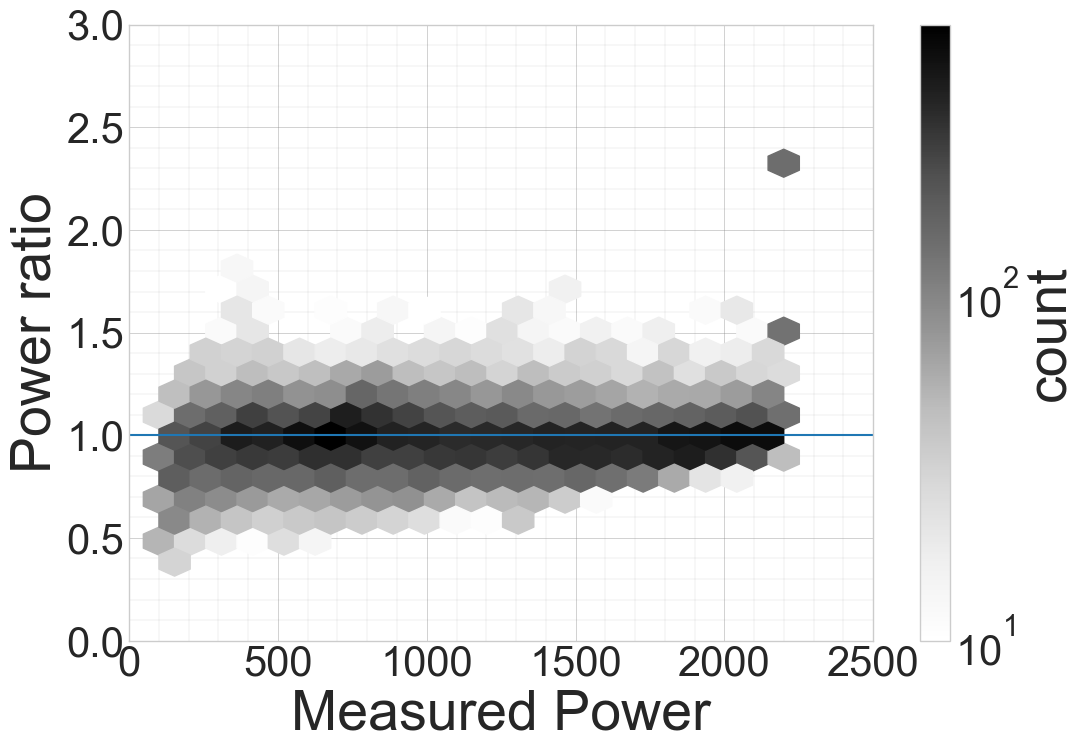

In [15]:
fig, ax = plt.subplots(figsize=(12,8))
tempdf = data_df[np.abs(data_df["targetwindvane"])>0.1]
hb = ax.hexbin(tempdf["power"], tempdf["power"]/tempdf["consensus_power_shifted"], gridsize=(20,50), mincnt=10, bins='log')
ax.plot([0,2500],[1,1])
fig.colorbar(hb, label='count')
ax.set_ylabel('Power ratio')
ax.set_xlabel('Measured Power')
ax.set_axisbelow(True)
ax.set_ylim(0,3)
ax.set_xlim(0,2500)
ax.grid(True, color='gray', linewidth=1.5, alpha=0.4)
ax.minorticks_on()
ax.grid(which='major', color='gray', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', color='gray', linewidth=0.3, alpha=0.3)
plt.show()

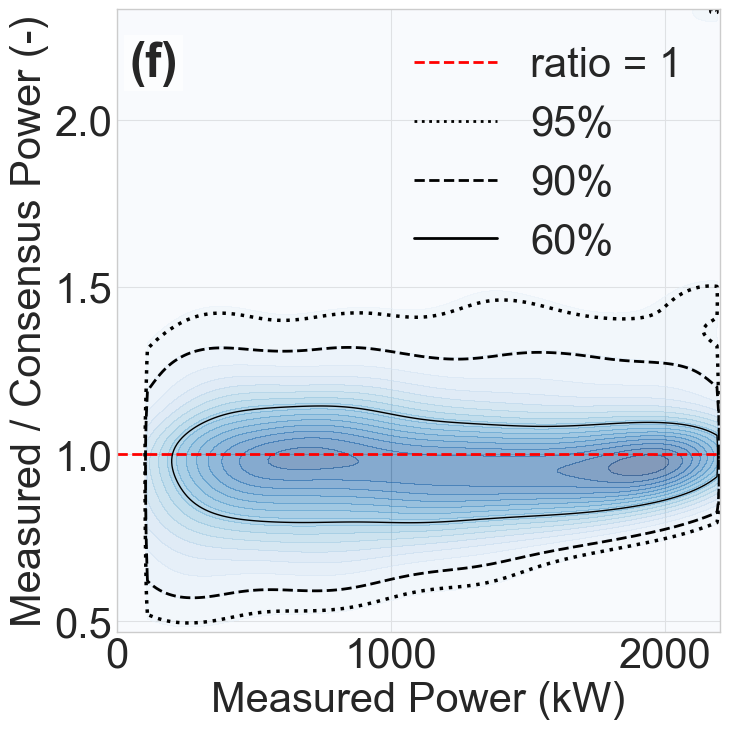

In [16]:
# ---------------------------------------------------------------------------
# 1. Filter
# ---------------------------------------------------------------------------
temp = data_df.dropna()
 
# Fixed: abs() around the column, not around the boolean comparison.
temp = temp[np.abs(temp["targetwindvane"]) > 0.1]
 
# New: guard against zero/near-zero/negative consensus power, which is what
# turns power/consensus into +/-inf or NaN and breaks gaussian_kde. Pick a
# floor that matches your data (e.g. a small fraction of rated power, or
# simply > 0 if negative/zero consensus values are just sensor artifacts).
consensus_floor = 10.0  # kW -- adjust to taste
temp = temp[temp["consensus_power_shifted"] > consensus_floor]
 
# ---------------------------------------------------------------------------
# 2. Sample
# ---------------------------------------------------------------------------
n_samples = 2000  # choose what you want
 
df_sub = temp.sample(
    n=min(n_samples, len(temp)),
    random_state=0,  # reproducibility
)
 
x = df_sub["power"].values
y = df_sub["power"].values / df_sub["consensus_power_shifted"].values
 
# Belt-and-suspenders: drop any remaining non-finite pairs before fitting.
finite_mask = np.isfinite(x) & np.isfinite(y)
x, y = x[finite_mask], y[finite_mask]
 
# ---------------------------------------------------------------------------
# 3. KDE
# ---------------------------------------------------------------------------
values = np.vstack([x, y])
kde = gaussian_kde(values)
 
# Grid limits: x stays on the power scale, y now needs its OWN scale sized
# to the ratio's actual spread. Percentile-based so a few extreme ratios
# (e.g. from a value just above the consensus_floor) don't blow out the axis.
xmin, xmax = 0, 2200
ymin = max(0, np.nanpercentile(y, 0.5))
ymax = np.nanpercentile(y, 99.5)
 
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(positions).reshape(xx.shape)
 
# Enforce upper/lower limits using the SAME sampled data the KDE was fit on
# (previously this mixed in `temp`, the full pre-sample frame, which is
# inconsistent and -- since it still contained the unfiltered ratio in one
# earlier version of this bug -- could itself carry an inf into np.max/np.min).
zz[xx > np.max(x)] = 0
zz[yy > np.max(y)] = 0
zz[xx < np.min(x)] = 0
zz[yy < np.min(y)] = 0
 

 
levels = [
    find_level(zz, 0.60),
    find_level(zz, 0.90),
    find_level(zz, 0.95),
]
 
# ---------------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 8))
 
ax.contourf(xx, yy, zz, cmap="Blues", levels=20, alpha=0.5)
 
# Reference line: with y = ratio, "perfect agreement" is a HORIZONTAL line
# at ratio = 1, not the y = x diagonal (that only made sense when both axes
# were the same power quantity).
ax.axhline(1.0, linestyle="--", linewidth=2, color="red", label="ratio = 1")
 
contour_colors = ["black", "black", "black"]
contour_labels = ["95%", "90%", "60%"]
linestyles = [":", "--", "-"]
linewidths = [2.5, 2.0, 1.0]
cs = ax.contour(
    xx, yy, zz,
    levels=levels[::-1],
    colors=contour_colors,
    linewidths=linewidths,
    linestyles=linestyles,
)
 
contour_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=ls, label=f"{p}")
    for ls, p in zip(linestyles, contour_labels)
]
 
handles, labels = ax.get_legend_handles_labels()
handles += contour_handles
ax.legend(handles=handles, fontsize=30, loc="best", frameon=False)
ax.text(
    0.02, 0.95, '(f)',
    transform=ax.transAxes,
    fontsize=35,
    fontweight='bold',
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7),
)
 
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
 
ax.set_xlabel('Measured Power ' + r'(kW)', fontsize=30)
ax.set_ylabel('Measured / Consensus Power ' + r'(-)', fontsize=30)
# Uncomment if this panel sits in a row sharing a y-axis with a labeled panel:
# ax.set_yticklabels([])
 
plt.rcParams.update({
    "font.size": 30,
    "axes.labelsize": 40,
    "axes.titlesize": 20,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 20,
})
 
plt.tight_layout()
plt.savefig("power_ratio_kde_contours_STEERED.png", bbox_inches="tight")
plt.show()

## Split the data into training and validation

In [17]:
steered = data_df[data_df["targetwindvane"].abs() > 0.1]
train_folds, valid_folds = time_series_kfold(steered,5)

# Step 2: Windvane

Index(['ts', 'turbine', 'winddir', 'windspeed', 'windvane', 'power', 'nacdir',
       'targetwindvane', 'ti', 'state', 'circ_dif_mean', 'circ_dif_std',
       'ratio_std_comp', 'farm_z_wd', 'screened', 'seg_offset', 'seg',
       'windvane_cp', 'n_breaks', 'consensus_windvane', 'consensus_windspeed',
       'consensus_power'],
      dtype='str')

Use: "power", "ti", "windvane"

### LR

In [18]:
# median (50% quantile) linear model — matches the paper's selection criterion
windvane_inputs = ["power", "ti", "windvane"]
windvane_output = "consensus_windvane_shifted"

wv_res_lr = cv_evaluate(train_folds, valid_folds,
                     windvane_inputs, windvane_output,
                     lr_median_predictor, circular=True)   # circular=True for vane
# res_lr has rmse_folds, r2_folds, n_test, rmse, r2
print("LR median:", wv_res_lr["rmse"], wv_res_lr["r2"])

Fold 0: RMSE = 3.4371  R2 = 0.8429  (n_test=6096)
Fold 1: RMSE = 3.7698  R2 = 0.8393  (n_test=3165)
Fold 2: RMSE = 4.1497  R2 = 0.8185  (n_test=3496)
Fold 3: RMSE = 4.2975  R2 = 0.8984  (n_test=5659)
Fold 4: RMSE = 4.0828  R2 = 0.8826  (n_test=4061)

Mean RMSE: 3.9474 | Mean R2: 0.8563
LR median: 3.94739204972079 0.8563393090748923


### GB

In [19]:
windvane_inputs = ["power", "ti", "windvane"]
windvane_output = "consensus_windvane_shifted"

# 1. tune (selection on RMSE, one fit per subsample x depth)
wv_results, wv_best = tune_xgb_quantile(
    train_folds, valid_folds, windvane_inputs, windvane_output,
    round_grid=[2000, 2500, 3000, 5000],   # more rounds to compensate for slower eta
    subsample_grid=[0.05, 0.1, 0.5, 0.9],
    max_depth_grid=[1, 2, 3],
    learning_rate=0.1,                          # was default 0.3
    quantile=0.5, device="cuda", circular=True,
)
print("best hyperparameters:", wv_best["num_round"], wv_best["subsample"], wv_best["max_depth"])

# 2. score the winning config through the SAME harness as LR
wv_res_gb = cv_evaluate(
    train_folds, valid_folds, windvane_inputs, windvane_output,
    make_xgb_predictor(wv_best["params"], wv_best["num_round"]),
    circular=False,
)
# res_gb has the identical shape to res_lr: rmse_folds, r2_folds, n_test, rmse, r2

sub=0.05   depth=1 round=2000  RMSE=3.9791
sub=0.05   depth=1 round=2500  RMSE=3.9828
sub=0.05   depth=1 round=3000  RMSE=3.9807
sub=0.05   depth=1 round=5000  RMSE=3.9770
sub=0.05   depth=2 round=2000  RMSE=4.0221
sub=0.05   depth=2 round=2500  RMSE=4.0184
sub=0.05   depth=2 round=3000  RMSE=4.0409
sub=0.05   depth=2 round=5000  RMSE=4.0537
sub=0.05   depth=3 round=2000  RMSE=4.1119
sub=0.05   depth=3 round=2500  RMSE=4.1399
sub=0.05   depth=3 round=3000  RMSE=4.1494
sub=0.05   depth=3 round=5000  RMSE=4.2235
sub=0.1    depth=1 round=2000  RMSE=3.9770
sub=0.1    depth=1 round=2500  RMSE=3.9822
sub=0.1    depth=1 round=3000  RMSE=3.9830
sub=0.1    depth=1 round=5000  RMSE=3.9919
sub=0.1    depth=2 round=2000  RMSE=3.9788
sub=0.1    depth=2 round=2500  RMSE=3.9917
sub=0.1    depth=2 round=3000  RMSE=4.0025
sub=0.1    depth=2 round=5000  RMSE=4.0413
sub=0.1    depth=3 round=2000  RMSE=4.0772
sub=0.1    depth=3 round=2500  RMSE=4.0937
sub=0.1    depth=3 round=3000  RMSE=4.0990
sub=0.1    

In [20]:
print("GB median:", wv_res_gb["rmse"], wv_res_gb["r2"])
print(wv_best["max_depth"])

GB median: 3.9424995673589494 0.8539173336846291
2


In [21]:
wv_best

{'num_round': 2000,
 'subsample': 0.9,
 'max_depth': 2,
 'params': {'objective': 'reg:quantileerror',
  'quantile_alpha': 0.5,
  'device': 'cuda',
  'subsample': 0.9,
  'max_depth': 2,
  'eta': 0.1},
 'rmse': 3.9424995673589494,
 'rmse_folds': [3.8907397365814362,
  3.6963738525062215,
  3.9885264272825474,
  4.1283761756824475,
  4.008481644742095]}

# Step 3: Windspeed

### LR

In [22]:
# median (50% quantile) linear model — matches the paper's selection criterion
windspeed_inputs = ["windspeed", "ti", "windvane"]
windspeed_output = "consensus_windspeed_shifted"

ws_res_lr = cv_evaluate(train_folds, valid_folds,
                     windspeed_inputs, windspeed_output,
                     lr_median_predictor, circular=False)   # circular=True for vane
# res_lr has rmse_folds, r2_folds, n_test, rmse, r2
print("LR median:", ws_res_lr["rmse"], ws_res_lr["r2"])

Fold 0: RMSE = 0.6036  R2 = 0.9123  (n_test=6096)
Fold 1: RMSE = 0.7367  R2 = 0.8600  (n_test=3165)
Fold 2: RMSE = 0.7717  R2 = 0.8680  (n_test=3496)
Fold 3: RMSE = 0.8126  R2 = 0.8862  (n_test=5659)
Fold 4: RMSE = 0.7617  R2 = 0.9077  (n_test=4061)

Mean RMSE: 0.7373 | Mean R2: 0.8868
LR median: 0.7372622069245582 0.8868256534087051


### GB

In [23]:
windspeed_inputs = ["windspeed", "ti", "windvane"]
windspeed_output = "consensus_windspeed_shifted"

# 1. tune (selection on RMSE, one fit per subsample x depth)
ws_results, ws_best = tune_xgb_quantile(
    train_folds, valid_folds, windspeed_inputs, windspeed_output,
    round_grid=[2000, 2500, 3000, 5000],   # more rounds to compensate for slower eta
    subsample_grid=[0.05, 0.1, 0.5, 0.9],
    max_depth_grid=[1, 2, 3],
    learning_rate=0.1,                          # was default 0.3
    quantile=0.5, device="cuda", circular=False,
)
print("best hyperparameters:", ws_best["num_round"], ws_best["subsample"], ws_best["max_depth"])

# 2. score the winning config through the SAME harness as LR
ws_res_gb = cv_evaluate(
    train_folds, valid_folds, windspeed_inputs, windspeed_output,
    make_xgb_predictor(ws_best["params"], ws_best["num_round"]),
    circular=False,
)
# res_gb has the identical shape to res_lr: rmse_folds, r2_folds, n_test, rmse, r2

sub=0.05   depth=1 round=2000  RMSE=0.7319
sub=0.05   depth=1 round=2500  RMSE=0.7315
sub=0.05   depth=1 round=3000  RMSE=0.7345
sub=0.05   depth=1 round=5000  RMSE=0.7343
sub=0.05   depth=2 round=2000  RMSE=0.7333
sub=0.05   depth=2 round=2500  RMSE=0.7366
sub=0.05   depth=2 round=3000  RMSE=0.7382
sub=0.05   depth=2 round=5000  RMSE=0.7415
sub=0.05   depth=3 round=2000  RMSE=0.7579
sub=0.05   depth=3 round=2500  RMSE=0.7609
sub=0.05   depth=3 round=3000  RMSE=0.7634
sub=0.05   depth=3 round=5000  RMSE=0.7746
sub=0.1    depth=1 round=2000  RMSE=0.7295
sub=0.1    depth=1 round=2500  RMSE=0.7310
sub=0.1    depth=1 round=3000  RMSE=0.7321
sub=0.1    depth=1 round=5000  RMSE=0.7327
sub=0.1    depth=2 round=2000  RMSE=0.7312
sub=0.1    depth=2 round=2500  RMSE=0.7328
sub=0.1    depth=2 round=3000  RMSE=0.7339
sub=0.1    depth=2 round=5000  RMSE=0.7385
sub=0.1    depth=3 round=2000  RMSE=0.7473
sub=0.1    depth=3 round=2500  RMSE=0.7521
sub=0.1    depth=3 round=3000  RMSE=0.7551
sub=0.1    

In [24]:
print("GB median:", ws_res_gb["rmse"], ws_res_gb["r2"])
print(ws_best["max_depth"])

GB median: 0.7278105628248202 0.8890914891349727
2


In [25]:
ws_best

{'num_round': 2000,
 'subsample': 0.9,
 'max_depth': 2,
 'params': {'objective': 'reg:quantileerror',
  'quantile_alpha': 0.5,
  'device': 'cuda',
  'subsample': 0.9,
  'max_depth': 2,
  'eta': 0.1},
 'rmse': 0.7278105628248202,
 'rmse_folds': [0.5844043167171991,
  0.7421660463925411,
  0.7755215716281386,
  0.8039210184787653,
  0.7330398609074573]}

# Step 4: Power

Start with the cosine model:
Try learning using a log-transform. 
Compare to a plot where the data are binned into measured windvane vs. power, on all the steered datapoints
Include the scatter in the background. 

In [26]:
data_df.columns

Index(['ts', 'turbine', 'winddir', 'windspeed', 'windvane', 'power', 'nacdir',
       'targetwindvane', 'ti', 'state', 'circ_dif_mean', 'circ_dif_std',
       'ratio_std_comp', 'farm_z_wd', 'screened', 'seg_offset', 'seg',
       'windvane_cp', 'n_breaks', 'consensus_windvane', 'consensus_windspeed',
       'consensus_power', 'consensus_windvane_shifted',
       'consensus_windspeed_shifted', 'consensus_power_shifted'],
      dtype='str')

In [44]:
fits = fit_cosine_quantiles(data_df["windvane"],
                             data_df["power"] / data_df["consensus_power_shifted"] )
print("alpha, beta0:", {f"{int(t*100)}%": tuple(round(v, 3) for v in ab) for t, ab in fits.items()})
print("monotone alpha:", fits[0.05][0] >= fits[0.50][0] >= fits[0.95][0])

alpha, beta0: {'5%': (np.float64(3.295), np.float64(-0.247)), '50%': (np.float64(1.533), np.float64(0.005)), '95%': (np.float64(0.829), np.float64(0.344))}
monotone alpha: True


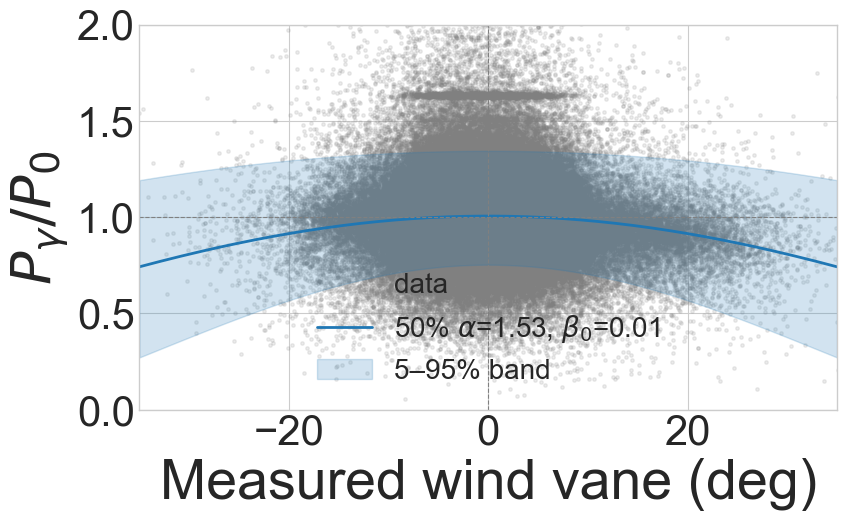

In [43]:
# --- visualize on test ---
u_test = data_df["windvane"].values * (np.pi/180)
y_test = data_df["power"].values / data_df["consensus_power"].values
good = np.isfinite(u_test) & np.isfinite(y_test) & (np.abs(u_test) < np.pi/2)
u_test, y_test = u_test[good], y_test[good]

# smooth curve over sorted vane for clean lines
u_line = np.linspace(-35*(np.pi/180), 35*(np.pi/180), 200)

alpha_50, beta0_50 = fits[0.50]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(np.degrees(u_test), y_test, s=6, alpha=0.15, color="gray", label="data")
ax.plot(np.degrees(u_line), cosine_model(fits[0.50], u_line),
        color="tab:blue", lw=2,
        label=fr"50% $\alpha$={alpha_50:.2f}, $\beta_0$={beta0_50:.2f}")
ax.fill_between(np.degrees(u_line),
                cosine_model(fits[0.05], u_line),
                cosine_model(fits[0.95], u_line),
                alpha=0.2, color="tab:blue", label="5–95% band")
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Measured wind vane (deg)")
ax.set_ylabel(r"$P_\gamma / P_0$")
ax.set_ylim(0, 2)
ax.set_xlim(-35,35)
ax.legend(loc="lower center")
plt.show()

### COSINE

In [29]:
cos_inputs = ["windvane", "power"]
power_output = "consensus_power_shifted"
fit_log = []
cos_predictor = make_cosine_quantile_predictor(
    cos_inputs, "windvane", "power", quantile=0.5,
    ratio_numerator="ref", fit_log=fit_log,
)
cos_result = cv_evaluate(train_folds, valid_folds, cos_inputs, power_output, cos_predictor)

Fold 0: RMSE = 177.4360  R2 = 0.9014  (n_test=6388)
Fold 1: RMSE = 322.9283  R2 = 0.6361  (n_test=5309)
Fold 2: RMSE = 201.0222  R2 = 0.8924  (n_test=4203)
Fold 3: RMSE = 205.7017  R2 = 0.8987  (n_test=5659)
Fold 4: RMSE = 198.4132  R2 = 0.9149  (n_test=4061)

Mean RMSE: 221.1003 | Mean R2: 0.8487


### LR

In [30]:
power_inputs = ["windvane", "ti", "power"]

pwr_lr_result = cv_evaluate(train_folds, valid_folds, power_inputs, power_output, lr_median_predictor)

Fold 0: RMSE = 181.5497  R2 = 0.8990  (n_test=6096)
Fold 1: RMSE = 403.3619  R2 = 0.4110  (n_test=3165)
Fold 2: RMSE = 196.5432  R2 = 0.9032  (n_test=3496)
Fold 3: RMSE = 205.4580  R2 = 0.8990  (n_test=5659)
Fold 4: RMSE = 203.2157  R2 = 0.9107  (n_test=4061)

Mean RMSE: 238.0257 | Mean R2: 0.8046


### GB

In [31]:
# 1. tune (selection on RMSE, one fit per subsample x depth)
pwr_results, pwr_best = tune_xgb_quantile(
    train_folds, valid_folds, power_inputs, power_output,
    round_grid=[2000, 2500, 3000, 5000],   # more rounds to compensate for slower eta
    subsample_grid=[0.05, 0.1, 0.5, 0.9],
    max_depth_grid=[1, 2, 3],
    learning_rate=0.1,                          # was default 0.3
    quantile=0.5, device="cuda", circular=False,
)

print("best hyperparameters:", pwr_best["num_round"], pwr_best["subsample"], pwr_best["max_depth"])

# 2. score the winning config through the SAME harness as LR
res_gb = cv_evaluate(
    train_folds, valid_folds, power_inputs, power_output,
    make_xgb_predictor(pwr_best["params"], pwr_best["num_round"]),
    circular=False,
)

sub=0.05   depth=1 round=2000  RMSE=224.6718
sub=0.05   depth=1 round=2500  RMSE=224.5520
sub=0.05   depth=1 round=3000  RMSE=225.6856
sub=0.05   depth=1 round=5000  RMSE=228.4497
sub=0.05   depth=2 round=2000  RMSE=223.1773
sub=0.05   depth=2 round=2500  RMSE=223.1921
sub=0.05   depth=2 round=3000  RMSE=223.8981
sub=0.05   depth=2 round=5000  RMSE=224.3936
sub=0.05   depth=3 round=2000  RMSE=226.6989
sub=0.05   depth=3 round=2500  RMSE=228.0527
sub=0.05   depth=3 round=3000  RMSE=229.0829
sub=0.05   depth=3 round=5000  RMSE=231.9032
sub=0.1    depth=1 round=2000  RMSE=226.0765
sub=0.1    depth=1 round=2500  RMSE=225.6159
sub=0.1    depth=1 round=3000  RMSE=226.5892
sub=0.1    depth=1 round=5000  RMSE=225.7684
sub=0.1    depth=2 round=2000  RMSE=220.8133
sub=0.1    depth=2 round=2500  RMSE=221.5587
sub=0.1    depth=2 round=3000  RMSE=221.5176
sub=0.1    depth=2 round=5000  RMSE=221.5291
sub=0.1    depth=3 round=2000  RMSE=224.8618
sub=0.1    depth=3 round=2500  RMSE=226.4589
sub=0.1   

# Step 5: Final Plots

### Windvane

In [32]:

# 1. all steered data, cleaned the same way as CV

windvane_inputs = ["power", "ti", "windvane"]
windvane_output = "consensus_windvane_shifted"

X_wv, y_wv, kept_wv = steered_xy(data_df, windvane_inputs, windvane_output, steer_thresh=0.1)

# 2a. GB: all three quantiles in one non-crossing fit, using CV-selected params
gb_params_wv = {"device": "cuda", "subsample": 0.9, "max_depth": 2, "eta": 0.1}
bst_wv, quantiles_wv = fit_ntf_xgb(X_wv, y_wv, params=gb_params_wv, num_round=2000,
                             quantiles=(0.05, 0.50, 0.95))

# 2b. LR: one linear quantile model per level (for the comparison panels)
lr_models_wv, _ = fit_ntf_lr(X_wv, y_wv, quantiles=(0.05, 0.50, 0.95))



<Axes: >

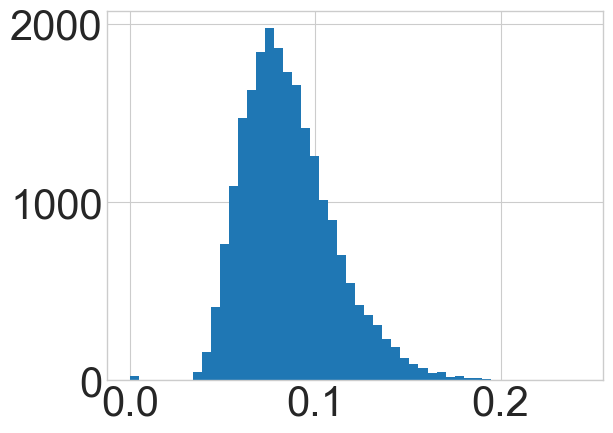

In [33]:
plt.rcParams.update({"font.size": 25})
kept_wv["ti"].hist(bins=50)

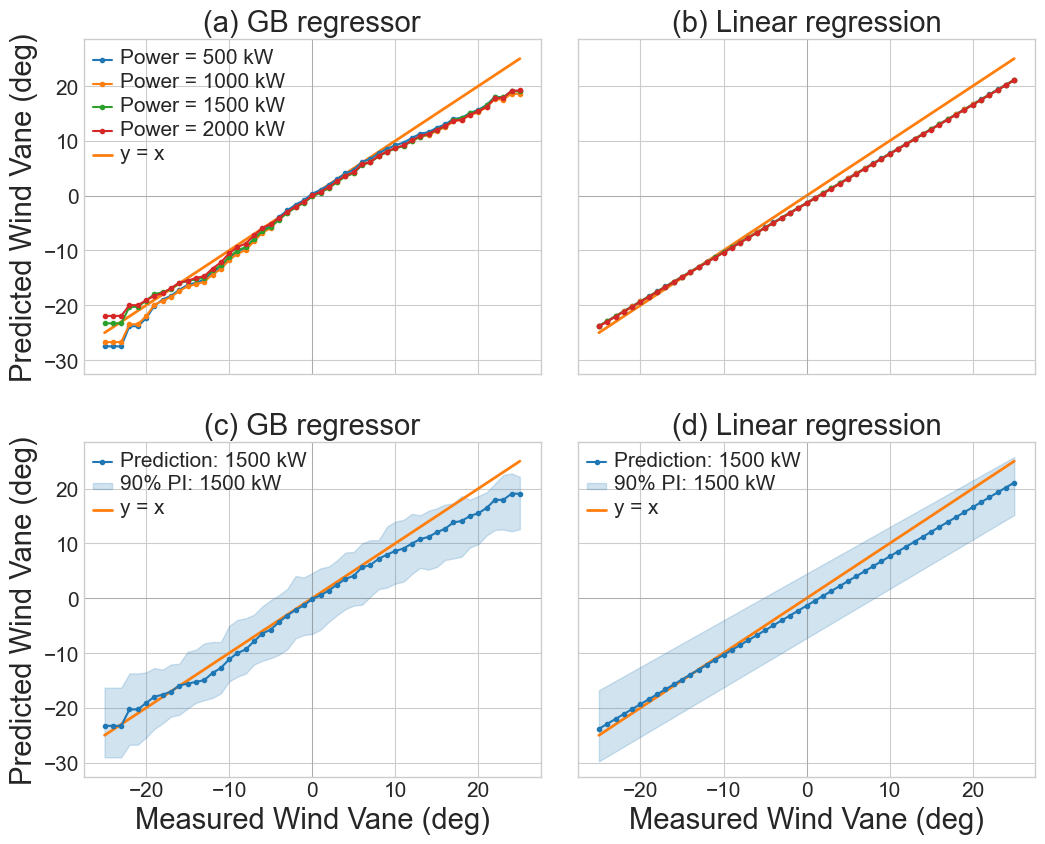

In [34]:
from ntf_plot import plot_ntf_figure

# 3. grid for plotting: sweep vane, hold TI at dataset mean, one curve per power (Fig 10)
ti_mean = kept_wv["ti"].quantile(0.5)


held_dict = {"ti": ti_mean}

vane_sweep = np.linspace(-25, 25, 51)

grid_gb_wv = predict_grid(lambda Xg: predict_xgb(bst_wv, Xg), windvane_inputs,
                       sweep="windvane", sweep_values=vane_sweep,
                       held=held_dict,
                       series=("power", [500, 1000, 1500, 2000]))

grid_lr_wv = predict_grid(lambda Xg: predict_lr(lr_models_wv, quantiles_wv, Xg), windvane_inputs,
                       sweep="windvane", sweep_values=vane_sweep,
                       held=held_dict,
                       series=("power", [500, 1000, 1500, 2000]))

fig, axes = plot_ntf_figure(
    grid_gb_wv, grid_lr_wv,
    sweep_col="windvane",
    series_col="power",
    quantiles=(0.05, 0.50, 0.95),
    envelope_level_index=2,          # third power level (1500 kW) gets the band, like the paper
    xlabel="Measured Wind Vane (deg)",
    ylabel="Predicted Wind Vane (deg)",
    series_label="Power", series_unit="kW",
    title=None,                      # <-- removes the overall suptitle
)
 
# plot_ntf_figure calls ax.set_xlabel/ax.set_ylabel with no fontsize, so these
# were inheriting an oversized rcParams default left over from earlier plots.
# Fix sizes directly on the returned axes instead of editing the function
# (so other figures that still want the larger size aren't affected).
style_axes(fig, axes)
 
 
fig.tight_layout()  # re-run now that label sizes have changed
fig.savefig("ntf_windvane.png", dpi=200, bbox_inches="tight")

### Windspeed

In [35]:
from ntf_fit import to_ratio_grid
# 1. all steered data, cleaned the same way as CV

windspeed_inputs = ["windspeed", "ti", "windvane"]
windspeed_output = "consensus_windspeed_shifted"

X_ws, y_ws, kept_ws = steered_xy(data_df, windspeed_inputs, windspeed_output, steer_thresh=0.1)

# 2a. GB: all three quantiles in one non-crossing fit, using CV-selected params
gb_params_ws = {"device": "cuda", "subsample": 0.9, "max_depth": 2, "eta": 0.1}
ws_bst, ws_quantiles = fit_ntf_xgb(X_ws, y_ws, params=gb_params_ws, num_round=2000,
                             quantiles=(0.05, 0.50, 0.95))

# 2b. LR: one linear quantile model per level (for the comparison panels)
ws_lr_models, _ = fit_ntf_lr(X_ws, y_ws, quantiles=(0.05, 0.50, 0.95))



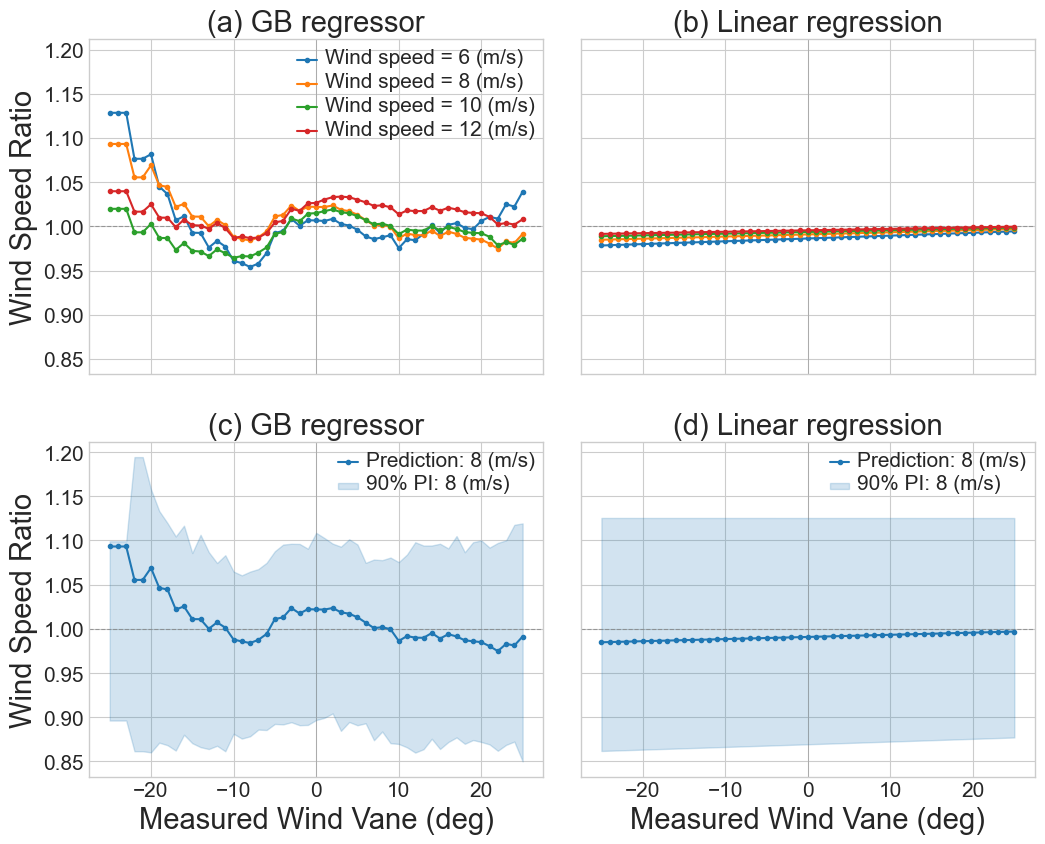

In [36]:
# 3. grid for plotting: sweep vane, hold TI at dataset mean, one curve per power (Fig 10)
ti_mean = kept_ws["ti"].quantile(0.5)

held_dict = {"ti": ti_mean}

vane_sweep = np.linspace(-25, 25, 51)

ws_grid_gb = predict_grid(lambda Xg: predict_xgb(ws_bst, Xg), windspeed_inputs,
                       sweep="windvane", sweep_values=vane_sweep,
                       held=held_dict,
                       series=("windspeed", [6,8,10,12]))

ws_grid_lr = predict_grid(lambda Xg: predict_lr(ws_lr_models, ws_quantiles, Xg), windspeed_inputs,
                       sweep="windvane", sweep_values=vane_sweep,
                       held=held_dict,
                       series=("windspeed", [6,8,10,12]))

ws_grid_gb = to_ratio_grid(ws_grid_gb, series_col="windspeed")
ws_grid_lr = to_ratio_grid(ws_grid_lr, series_col="windspeed")

fig, axes = plot_ntf_figure(ws_grid_gb, ws_grid_lr, sweep_col="windvane", series_col="windspeed",
                ratio=True, ylabel="Wind Speed Ratio",
                envelope_level_index=1,          # third power level (1500 kW) gets the band, like the paper
                series_label="Wind speed", series_unit="(m/s)",
                title=None)

# plot_ntf_figure calls ax.set_xlabel/ax.set_ylabel with no fontsize, so these
# were inheriting an oversized rcParams default left over from earlier plots.
# Fix sizes directly on the returned axes instead of editing the function
# (so other figures that still want the larger size aren't affected).
style_axes(fig, axes)
 
 
fig.tight_layout()  # re-run now that label sizes have changed
fig.savefig("ntf_windspeed.png", dpi=200, bbox_inches="tight")

### Power

In [37]:
from ntf_fit import to_ratio_grid
# 1. all steered data, cleaned the same way as CV

#data_df["windspeed_dif"] = data_df["consensus_windspeed"] - data_df["windspeed"]

power_inputs = ["power", "ti", "windvane"]
power_output = "consensus_power_shifted"

X_pwr, y_pwr, kept = steered_xy(data_df, power_inputs, power_output, steer_thresh=0.1)

# 2a. GB: all three quantiles in one non-crossing fit, using CV-selected params
gb_params_pwr = {"device": "cuda", "subsample": 0.1, "max_depth": 2, "eta": 0.1}
bst_pwr, quantiles_pwr = fit_ntf_xgb(X_pwr, y_pwr, params=gb_params_pwr, num_round=2000,
                             quantiles=(0.05, 0.50, 0.95))

# 2b. LR: one linear quantile model per level (for the comparison panels)
lr_models_pwr, _ = fit_ntf_lr(X_pwr, y_pwr, quantiles=(0.05, 0.50, 0.95))



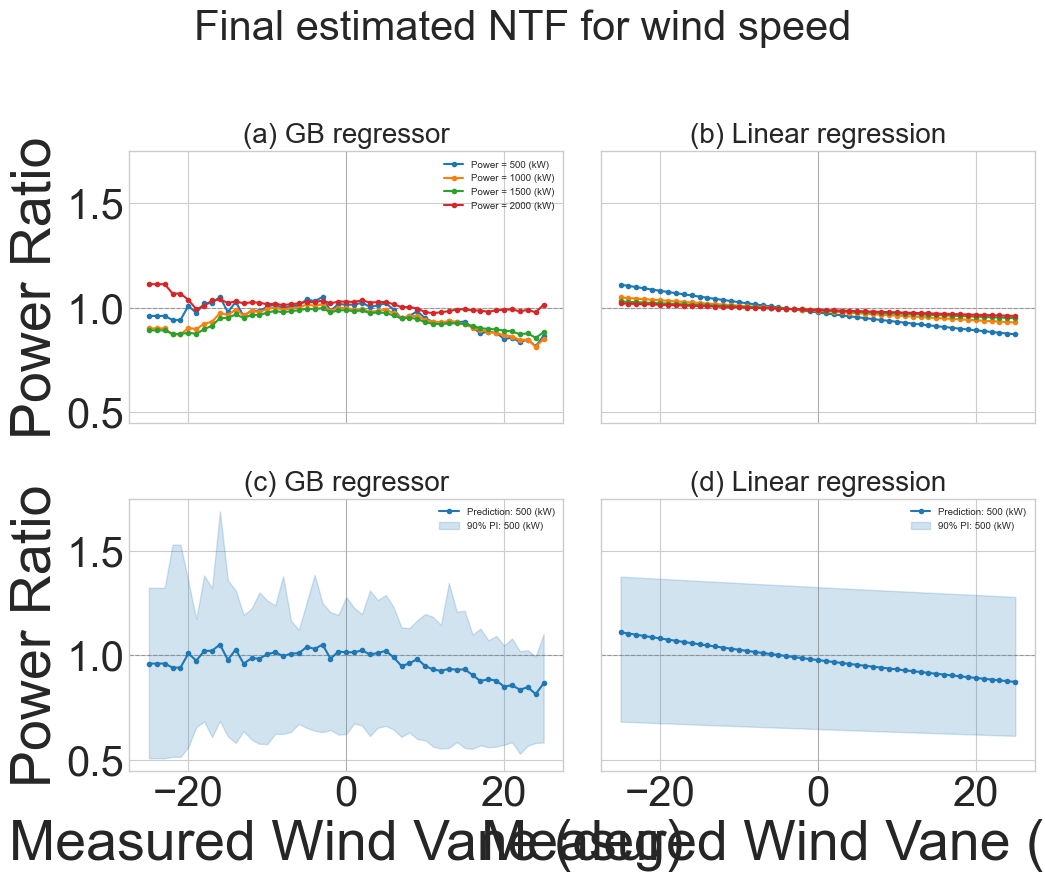

In [38]:
# 3. grid for plotting: sweep vane, hold TI at dataset mean, one curve per power (Fig 10)
ti_mean = kept["ti"].quantile(0.5)

held_dict = {"ti": ti_mean}

vane_sweep = np.linspace(-25, 25, 51)

p_grid_gb = predict_grid(lambda Xg: predict_xgb(bst_pwr, Xg), power_inputs,
                       sweep="windvane", sweep_values=vane_sweep,
                       held=held_dict,
                       series=("power", [500,1000,1500,2000]))

p_grid_lr = predict_grid(lambda Xg: predict_lr(lr_models_pwr, quantiles_pwr, Xg), power_inputs,
                       sweep="windvane", sweep_values=vane_sweep,
                       held=held_dict,
                       series=("power", [500,1000,1500,2000]))
                    
p_grid_gb = to_ratio_grid(p_grid_gb, series_col="power")
p_grid_lr = to_ratio_grid(p_grid_lr, series_col="power")


fig, axes = plot_ntf_figure(p_grid_gb, p_grid_lr, sweep_col="windvane", series_col="power",
                ratio=True, ylabel="Power Ratio",
                envelope_level_index=0,          # third power level (1500 kW) gets the band, like the paper
                series_label="Power", series_unit="(kW)",
                title="Final estimated NTF for wind speed")
fig.savefig("ntf_power_gb_lr.png", dpi=200, bbox_inches="tight")

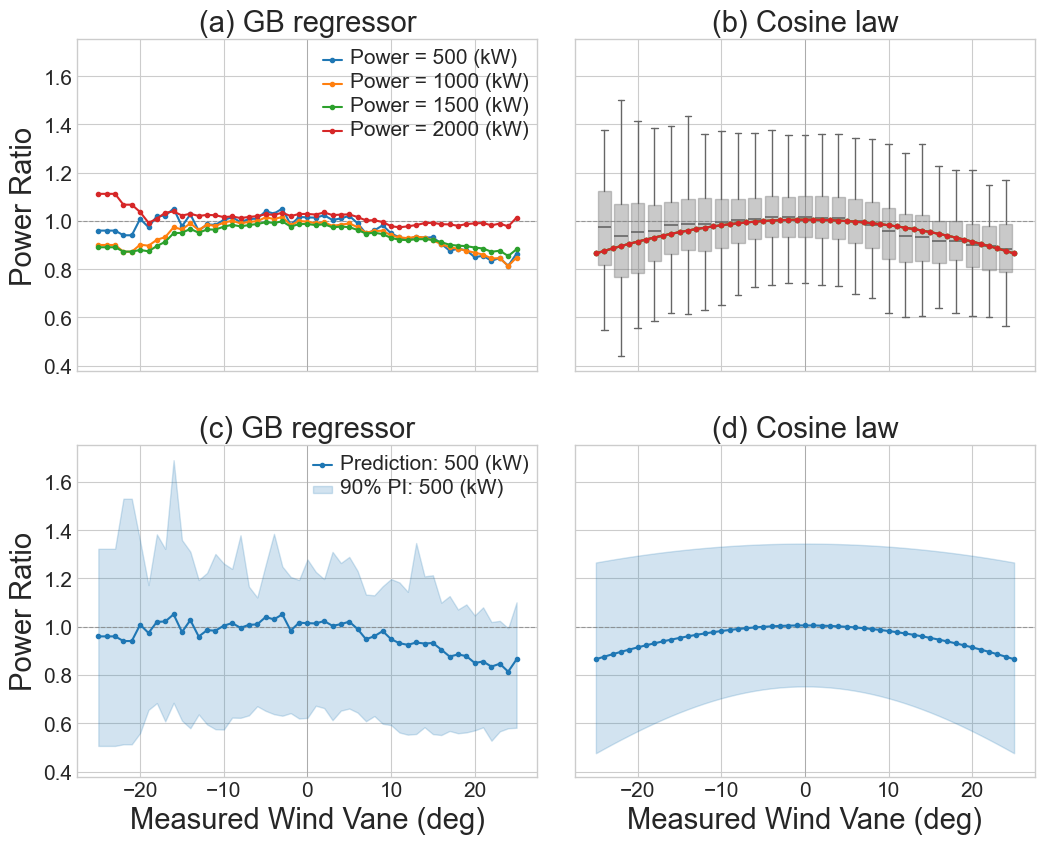

In [45]:
p_grid_cos = build_cosine_grid(fits, vane_sweep, "power", [500, 1000, 1500, 2000])
# fits here = the alpha/beta0-per-quantile dict from your cosine-law fit on the
# same power/consensus_power ratio -- q0/q1/q2 are already ratios, so no
# grid[col] = grid["power"]/grid[col] division needed for this column.
box_df = data_df[["windvane", "power", "consensus_power"]].copy()
box_df["ratio"] = box_df["power"] / box_df["consensus_power"]

# fig, axes = plot_ntf_figure(
#     [(p_grid_gb, "GB regressor"), (p_grid_lr, "Linear regression"), (p_grid_cos, "Cosine law")],
#     sweep_col="windvane", series_col="power",
#     ratio=True, ylabel="Power Ratio",
#     envelope_level_index=0,
#     series_label="Power", series_unit="(kW)",
#     title=None,
#     box_data=box_df, box_value_col="ratio", box_target_index=2, box_bin_width=2.0,
# )

fig, axes = plot_ntf_figure(
    [(p_grid_gb, "GB regressor"), (p_grid_cos, "Cosine law")],
    sweep_col="windvane", series_col="power",
    ratio=True, ylabel="Power Ratio",
    envelope_level_index=0,
    series_label="Power", series_unit="(kW)",
    title=None,
    box_data=box_df, box_value_col="ratio", box_target_index=1, box_bin_width=2.0,
)

# plot_ntf_figure calls ax.set_xlabel/ax.set_ylabel with no fontsize, so these
# were inheriting an oversized rcParams default left over from earlier plots.
# Fix sizes directly on the returned axes instead of editing the function
# (so other figures that still want the larger size aren't affected).
style_axes(fig, axes)
 
leg = axes[1, -1].get_legend()
if leg is not None:
    leg.remove() 
fig.tight_layout()  # re-run now that label sizes have changed
fig.savefig("ntf_power.png", dpi=200, bbox_inches="tight")

# GB UQ plots
Windvane | Windspeed | Power

0.017082069616200363
3.6440280392636004


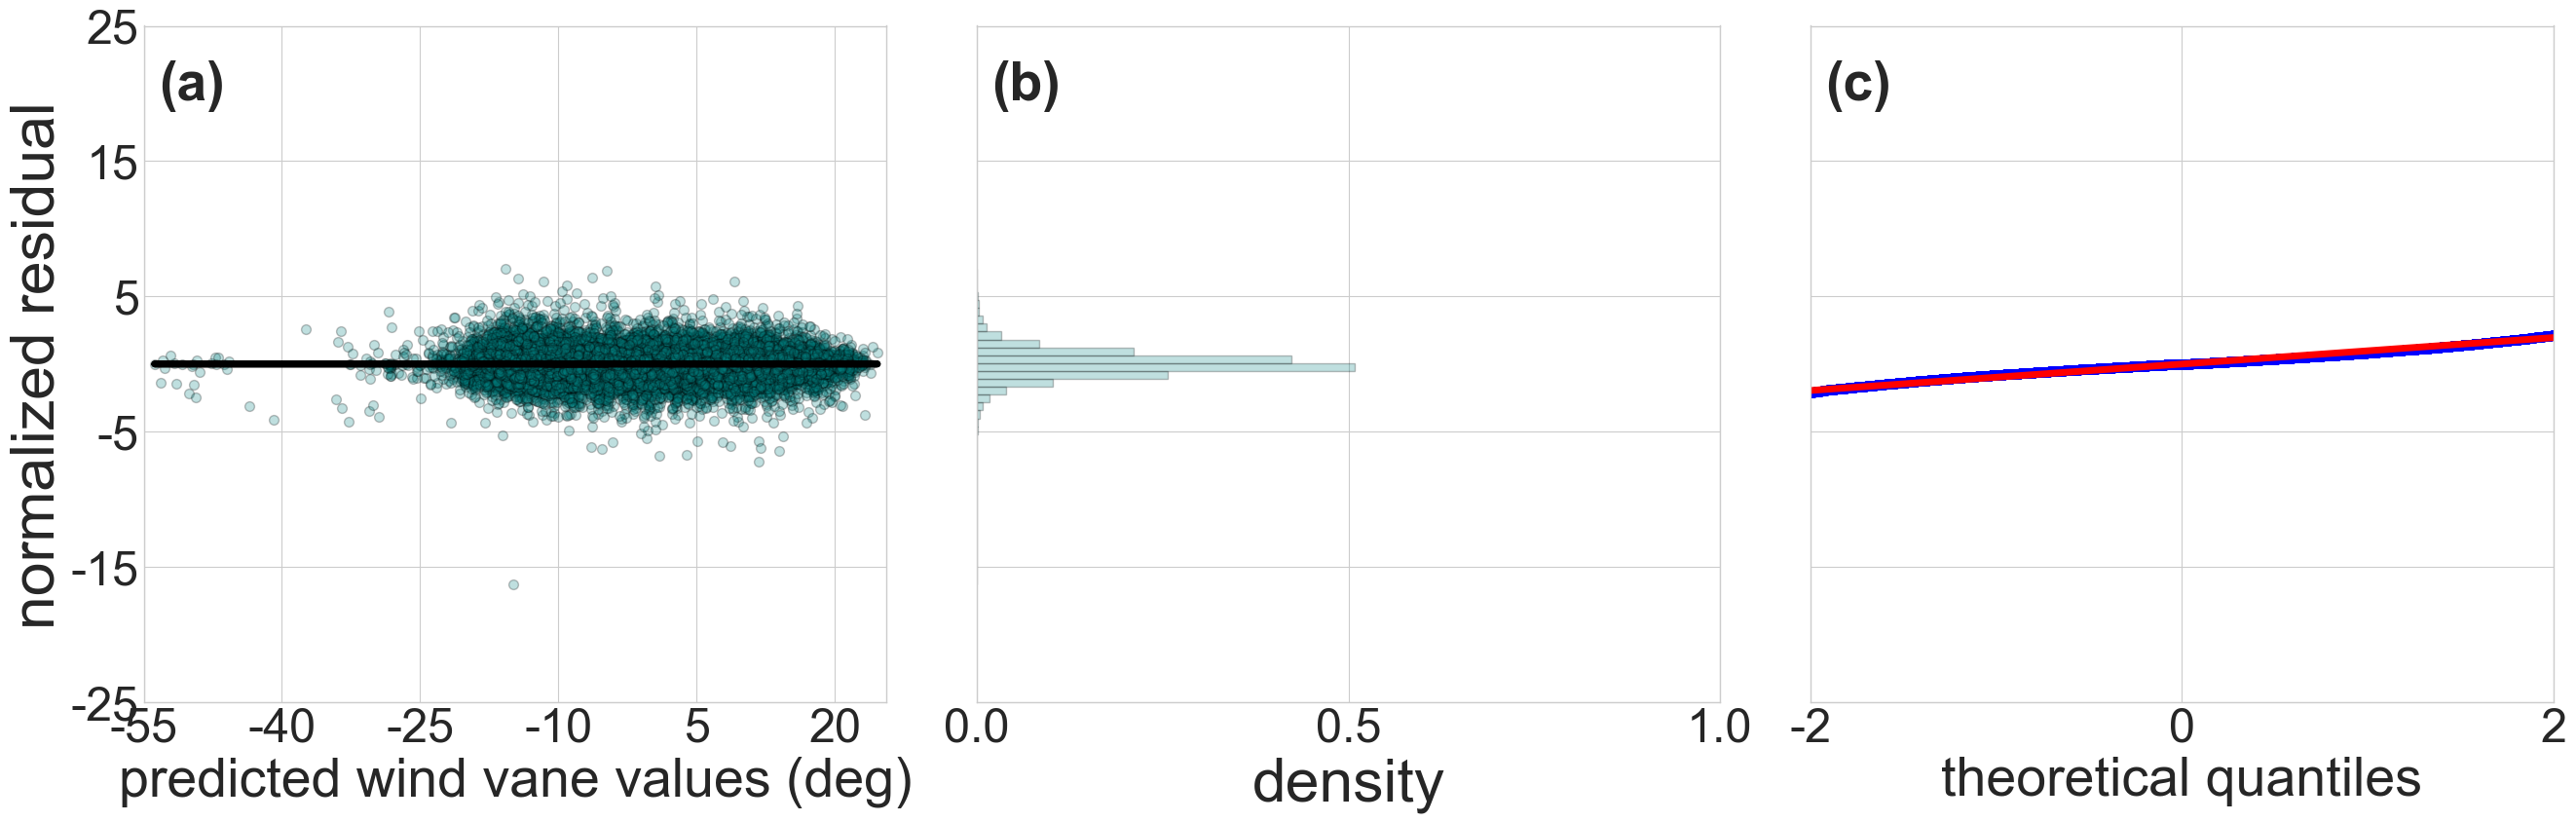

0.012482348726128347
0.6843514152361322


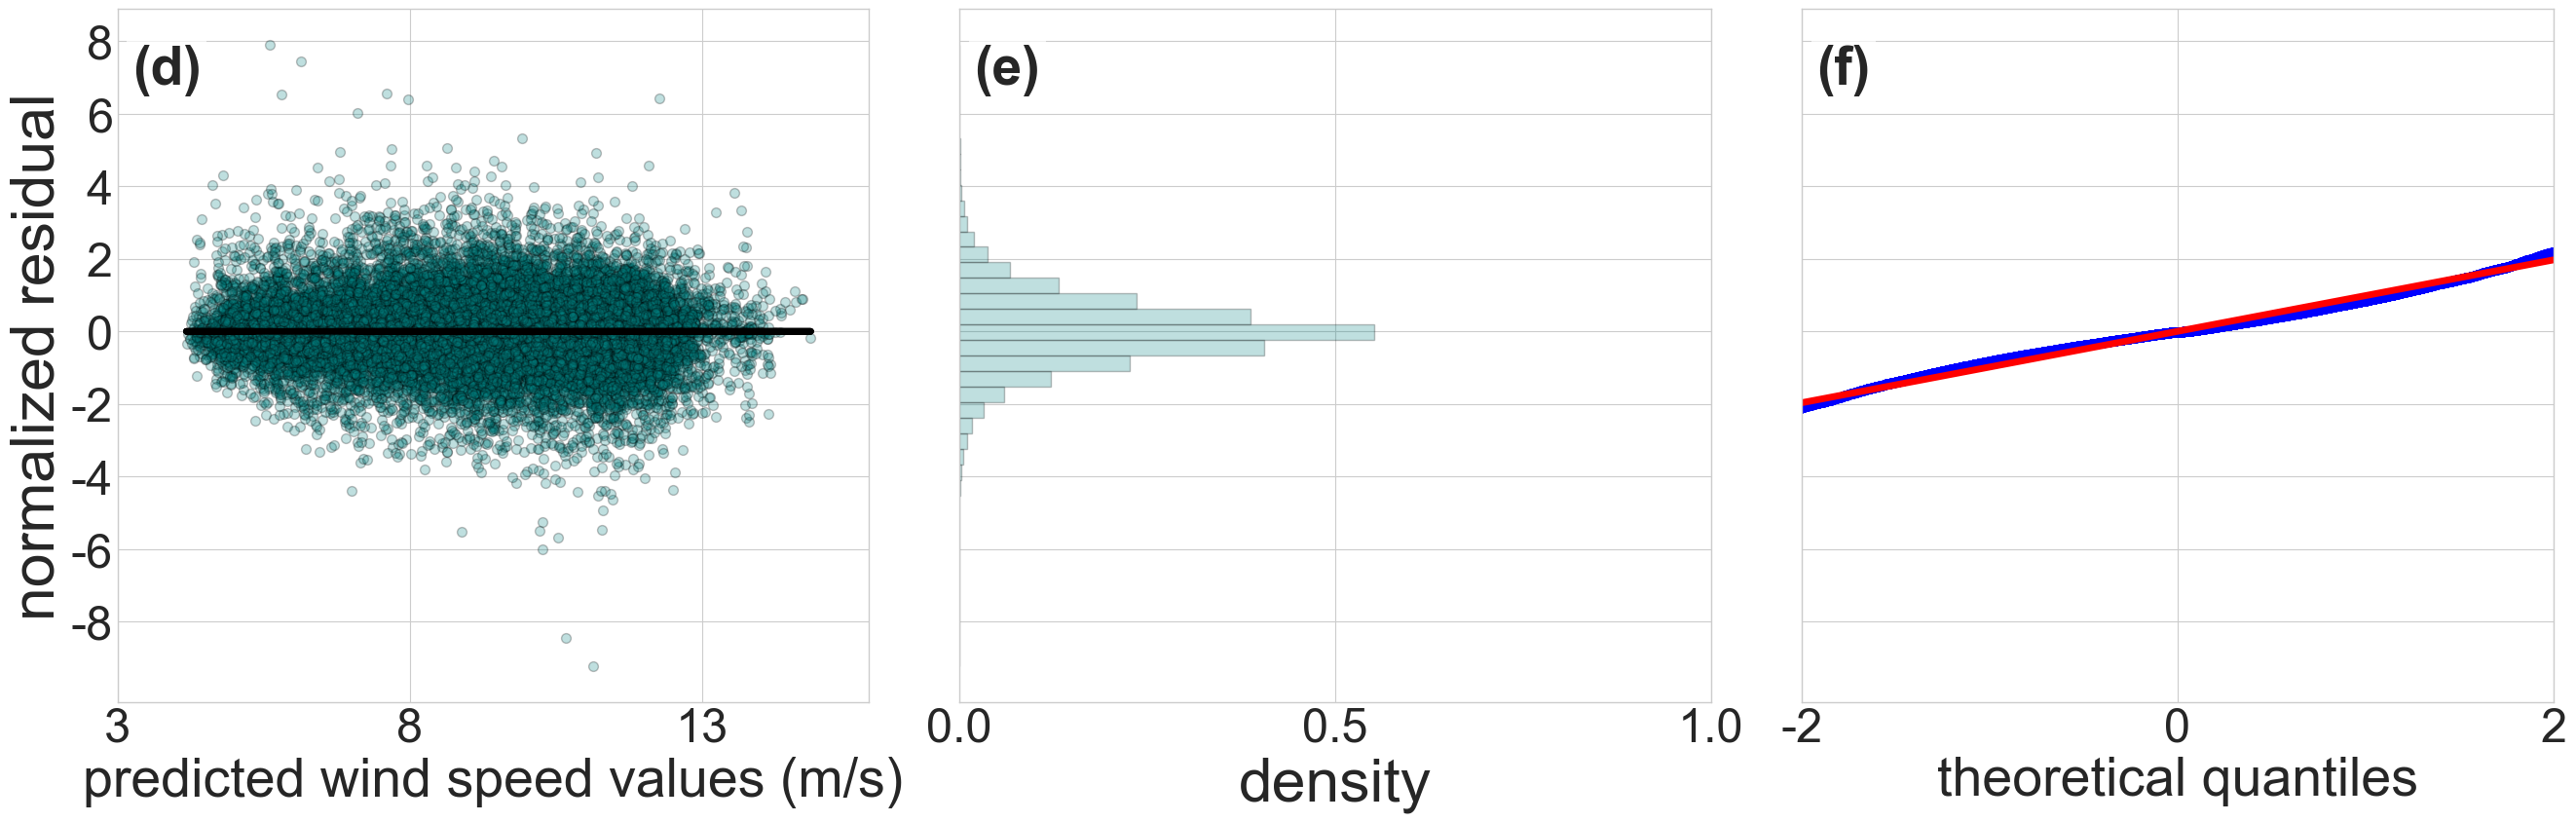

-0.1529215163169477
200.92398278037837


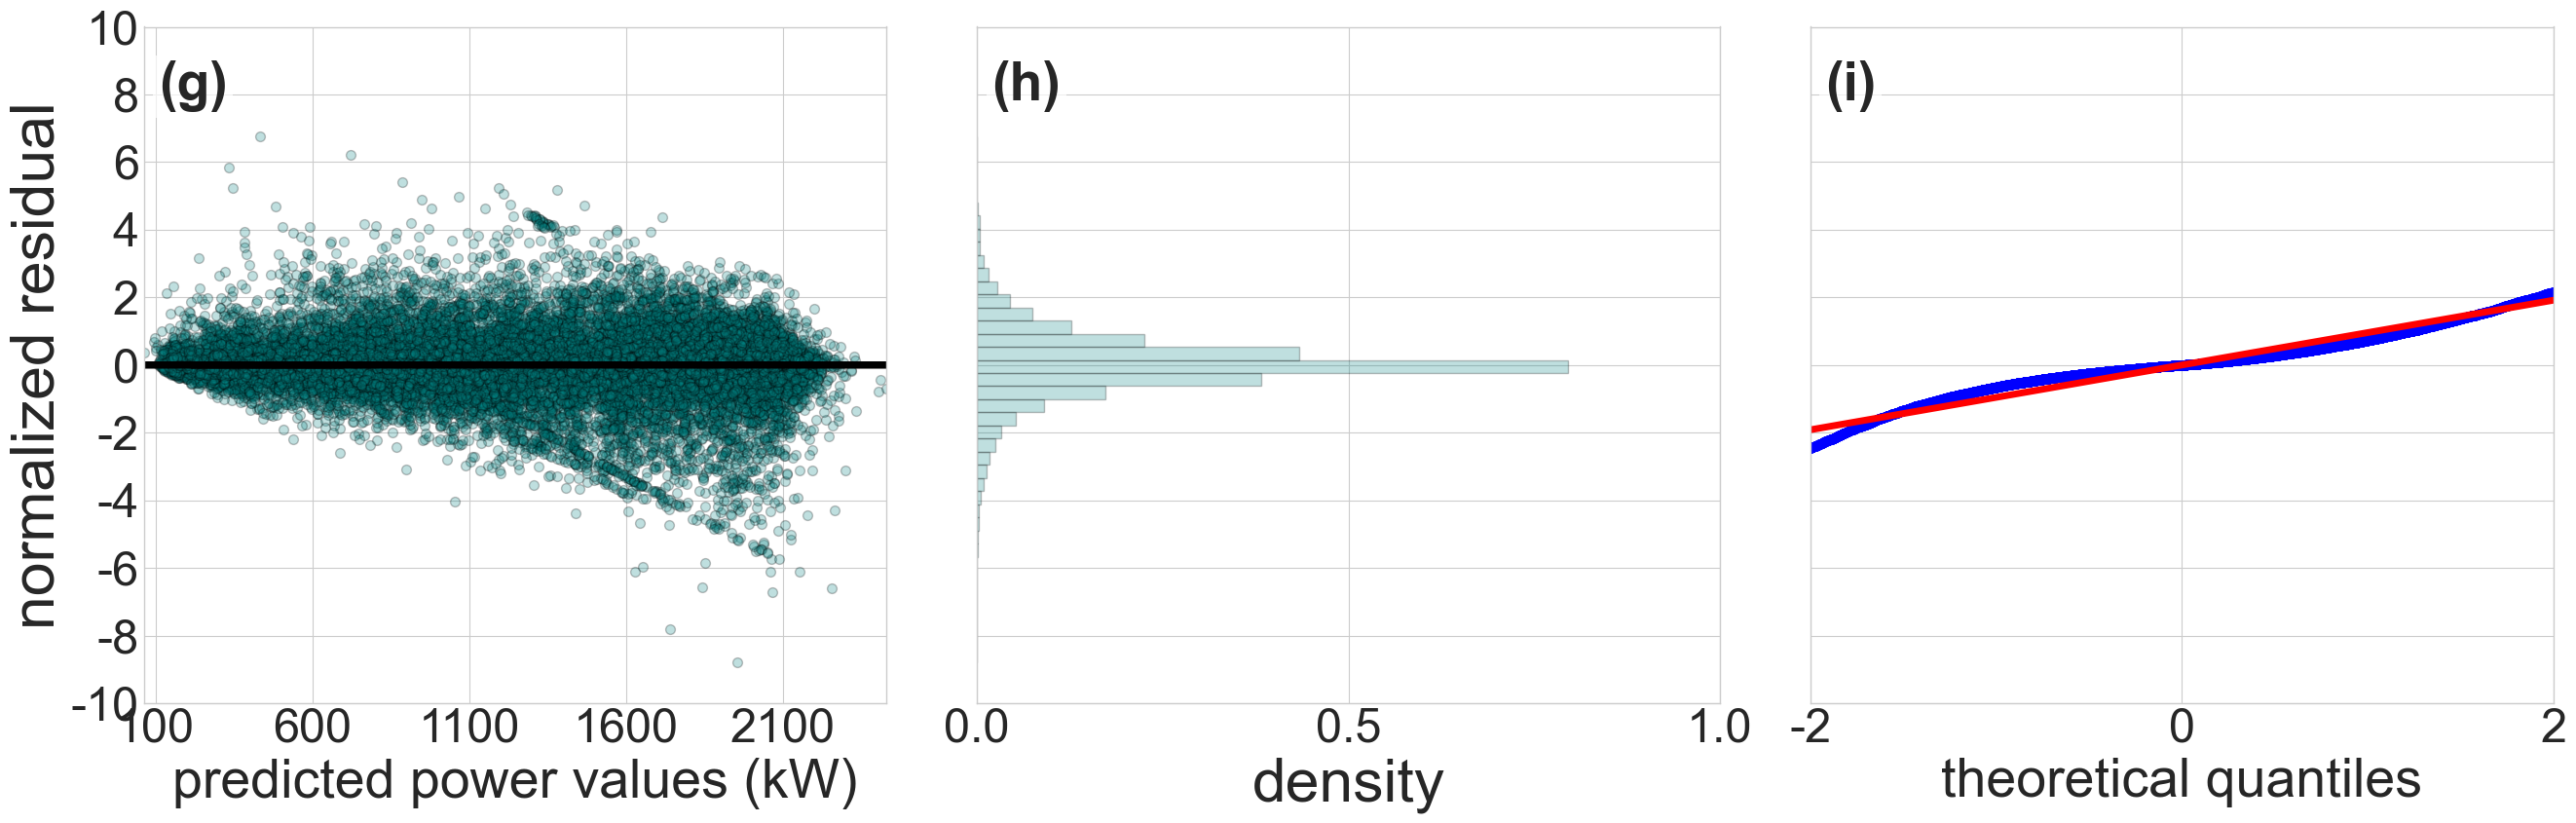

(<Figure size 2700x900 with 3 Axes>,
 array([<Axes: xlabel='predicted power values (kW)', ylabel='normalized residual'>,
        <Axes: xlabel='density'>, <Axes: xlabel='theoretical quantiles'>],
       dtype=object))

In [40]:
# cell 80 -- note y_wv: the old cell used `y`, a leftover variable from an
# earlier cell, not the target this model was fit on
plot_residual_diagnostics(bst_wv, X_wv, y_wv, quantiles_wv,
    xlabel="predicted wind vane values (deg)",
    xticks=np.arange(-55, 30, 15), yticks=np.arange(-25, 30, 10),
    panel_labels=("(a)", "(b)", "(c)"), fname="Figure_11a_windvane_updated.png")

# cell 82
plot_residual_diagnostics(ws_bst, X_ws, y_ws, ws_quantiles,
    xlabel="predicted wind speed values (m/s)",
    xticks=np.arange(3, 17, 5), yticks=np.arange(-8, 10, 2),
    panel_labels=("(d)", "(e)", "(f)"), fname="Figure_11a_windspeed_updated.png")

# cell 84
plot_residual_diagnostics(bst_pwr, X_pwr, y_pwr, quantiles_pwr,
    xlabel="predicted power values (kW)",
    xticks=np.arange(100, 2200, 500), yticks=np.arange(-10, 12, 2),
    panel_labels=("(g)", "(h)", "(i)"), fname="Figure_11a_power_updated.png")

# GB Predictor importance plots
Windvane | Windspeed | Power

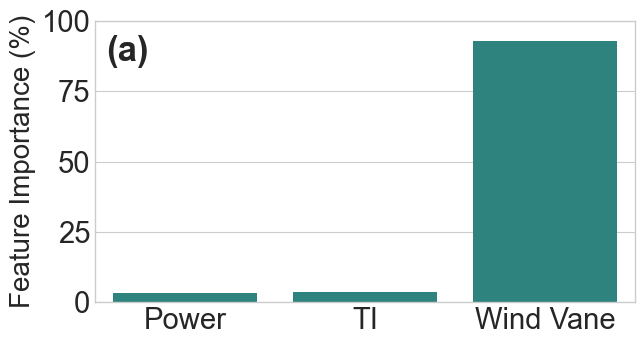

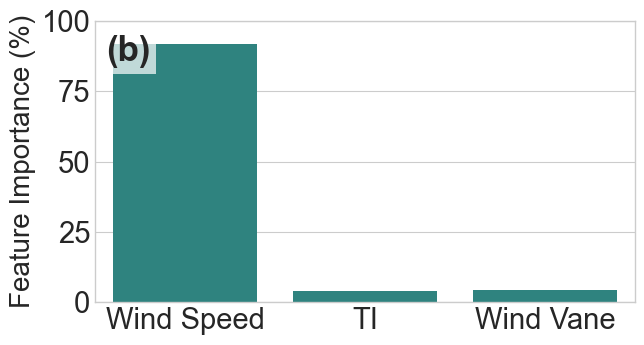

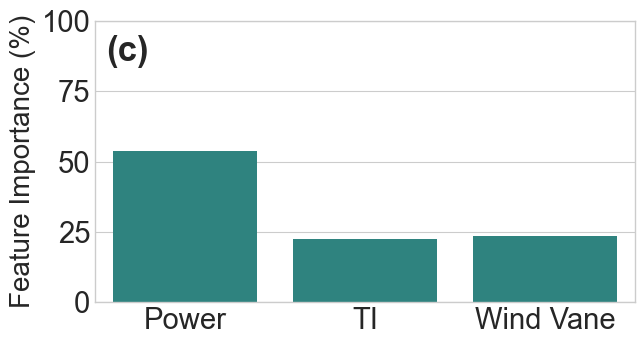

(<Figure size 700x400 with 1 Axes>, <Axes: ylabel='Feature Importance (%)'>)

In [41]:
plot_feature_importance(bst_wv, windvane_inputs,
    {"power": "Power", "ti": "TI", "windvane": "Wind Vane"},
    panel_label="(a)", fname="feature_importance_windvane_updated.png")

plot_feature_importance(ws_bst, windspeed_inputs,
    {"windspeed": "Wind Speed", "ti": "TI", "windvane": "Wind Vane"},
    panel_label="(b)", fname="feature_importance_windspeed_updated.png")

plot_feature_importance(bst_pwr, power_inputs,
    {"power": "Power", "ti": "TI", "windvane": "Wind Vane"},
    panel_label="(c)", fname="feature_importance_power_updated.png")